100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]



--- TRAINING PHASE ---
Epoch 1: Loss = 1.3092, Accuracy = 62.41%
Epoch 2: Loss = 0.9360, Accuracy = 68.22%
Epoch 3: Loss = 0.7759, Accuracy = 70.59%
Epoch 4: Loss = 0.6520, Accuracy = 71.93%
Epoch 5: Loss = 0.5359, Accuracy = 71.20%

--- PRUNING PHASE ---
Sparsity: 70.00%
Pruned Weights: 749302/1070432

--- FINE-TUNING PHASE ---
Fine-tune Epoch 1: Loss = 0.4890, Accuracy = 72.12%
Fine-tune Epoch 2: Loss = 0.3638, Accuracy = 71.69%
Fine-tune Epoch 3: Loss = 0.2702, Accuracy = 71.83%


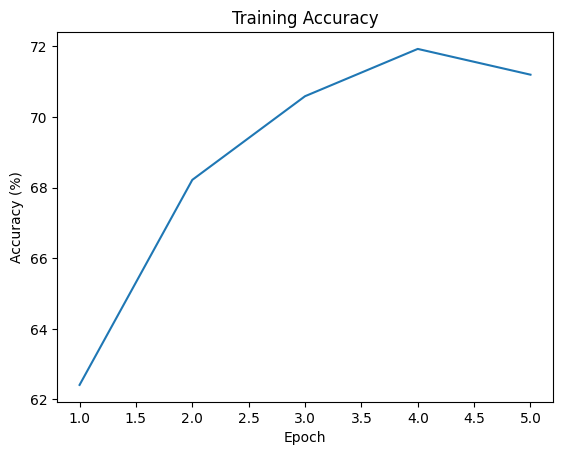

In [2]:


"""
Realistic CNN Pruning Pipeline (CIFAR-10)

Steps:
1. Train model
2. Apply magnitude pruning
3. Fine-tune
4. Report pruning statistics
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# 1. Model
# -----------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))  # 16x16 -> 8x8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# -----------------------------
# 2. Data Loader
# -----------------------------
def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ])

    train_data = datasets.CIFAR10('./data', train=True,
                                 download=True, transform=transform)
    test_data = datasets.CIFAR10('./data', train=False,
                                transform=transform)

    train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=64)

    return train_loader, test_loader


# -----------------------------
# 3. Train Function
# -----------------------------
def train(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


# -----------------------------
# 4. Evaluation
# -----------------------------
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            pred = out.argmax(1)

            total += y.size(0)
            correct += (pred == y).sum().item()

    return 100 * correct / total


# -----------------------------
# 5. Pruning Function
# -----------------------------
def prune_model(model, amount=0.5):
    total_params = 0
    pruned_params = 0

    for name, param in model.named_parameters():
        if "weight" in name:
            tensor = param.data.abs()

            threshold = torch.quantile(tensor, amount)

            mask = tensor > threshold

            pruned_params += (mask == 0).sum().item()
            total_params += mask.numel()

            param.data *= mask  # Apply pruning

    sparsity = 100 * pruned_params / total_params

    return sparsity, pruned_params, total_params


# -----------------------------
# 6. Main Pipeline
# -----------------------------
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, test_loader = get_data()

    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print("\n--- TRAINING PHASE ---")

    acc_history = []

    for epoch in range(5):
        loss = train(model, train_loader, optimizer, criterion, device)
        acc = evaluate(model, test_loader, device)

        acc_history.append(acc)

        print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Accuracy = {acc:.2f}%")

    # -----------------------------
    # Pruning
    # -----------------------------
    print("\n--- PRUNING PHASE ---")

    sparsity, pruned, total = prune_model(model, amount=0.7)

    print(f"Sparsity: {sparsity:.2f}%")
    print(f"Pruned Weights: {pruned}/{total}")

    # -----------------------------
    # Fine-tuning
    # -----------------------------
    print("\n--- FINE-TUNING PHASE ---")

    for epoch in range(3):
        loss = train(model, train_loader, optimizer, criterion, device)
        acc = evaluate(model, test_loader, device)

        print(f"Fine-tune Epoch {epoch+1}: Loss = {loss:.4f}, Accuracy = {acc:.2f}%")

    # -----------------------------
    # Plot Accuracy
    # -----------------------------
    plt.figure()
    plt.plot(range(1, len(acc_history) + 1), acc_history)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training Accuracy")
    plt.show()


# -----------------------------
# Run
# -----------------------------
if __name__ == "__main__":
    main()



